# <span style="font-size:16pt; font-weight:bold;">Notebook 24: Comprehensive HPO Analysis</span>


## <span style="font-size:14pt; font-weight:bold;">1. Setup</span>


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; import json; import warnings; warnings.filterwarnings('ignore')
REPO=Path.home()/'projects'/'music-prediction'
IMGS=REPO/'results/figures/thesis'; ANALYSIS=REPO/'results/analysis'; HPO=REPO/'results/hpo'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
TARGETS=['valence','energy','danceability','popularity']
TC={'valence':'#4C72B0','energy':'#DD8452','danceability':'#55A868','popularity':'#C44E52'}
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete.')


Setup complete.


In [2]:
def lj(p):
    if p.exists(): return json.loads(p.read_text())
    print(f'{p.name} not found'); return None
cp=lj(HPO/'catboost_best_params.json'); ap=lj(HPO/'attention_dl_best_params.json')


## <span style="font-size:14pt; font-weight:bold;">2. CatBoost HPO</span>


valence: 12 trials
energy: 12 trials
danceability: 12 trials
popularity: 12 trials


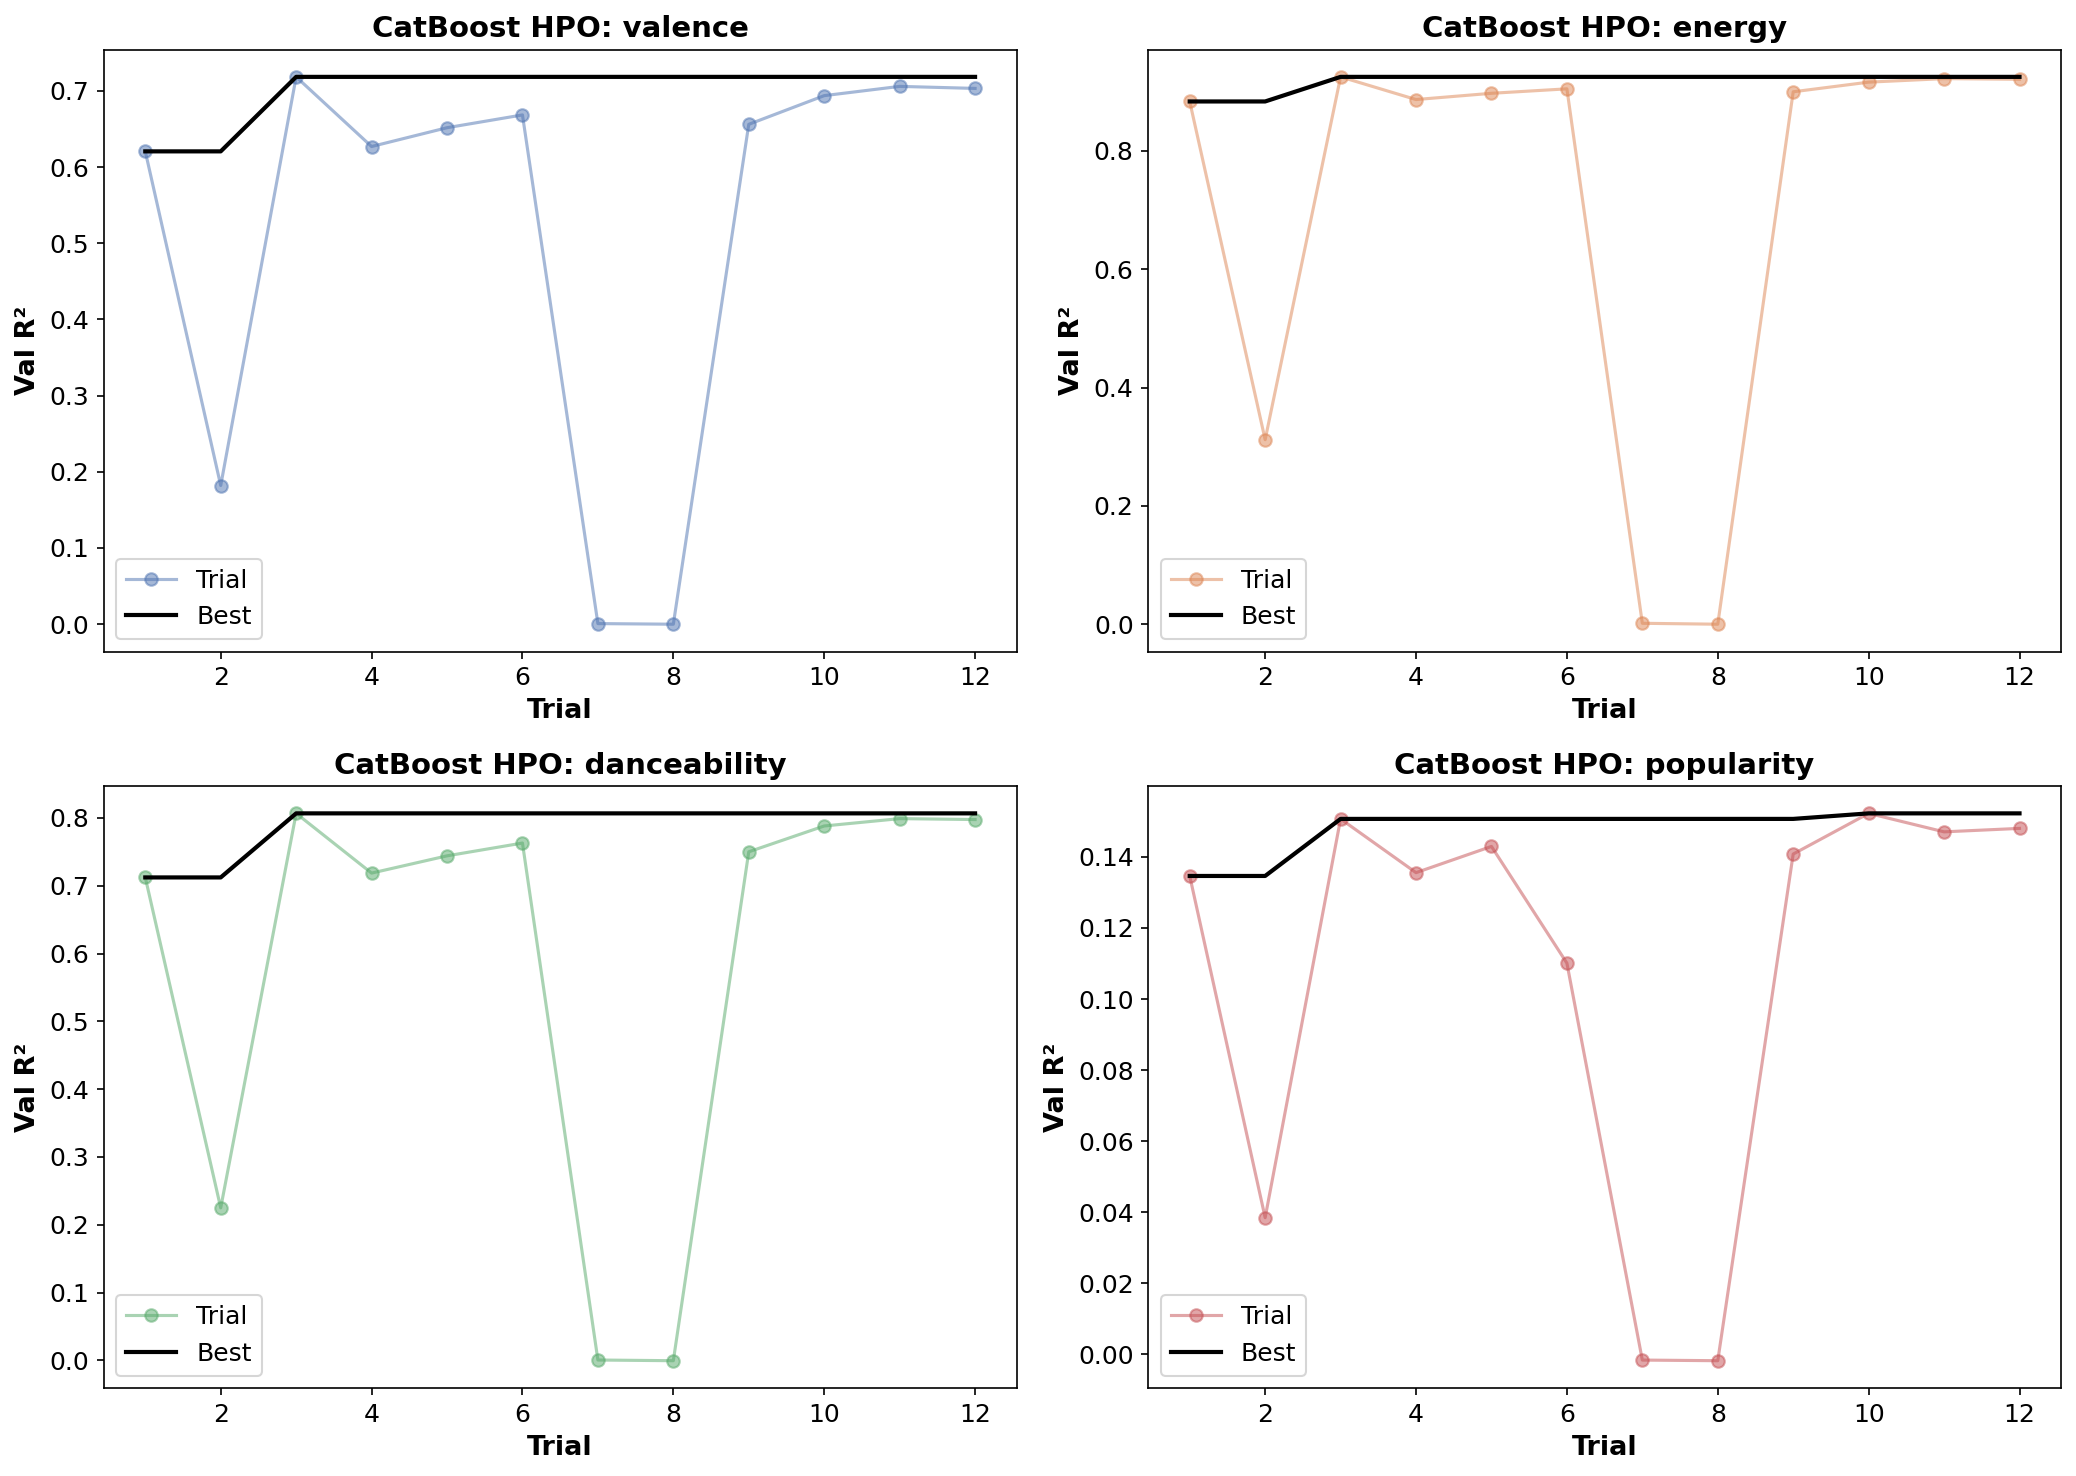

In [3]:
ct={}
for t in TARGETS:
    ms=sorted(HPO.glob(f'catboost_hpo_val_{t}_*.csv'))
    if ms: ct[t]=pd.read_csv(ms[-1]); print(f'{t}: {len(ct[t])} trials')
    else: print(f'{t}: no trial file')
if ct:
    fig,axes=plt.subplots(2,2,figsize=(14,10))
    for idx,t in enumerate(TARGETS):
        ax=axes[idx//2,idx%2]
        if t in ct:
            df=ct[t]; vc=[c for c in df.columns if 'value' in c.lower() or 'r2' in c.lower()]
            if vc: ax.plot(range(1,len(df)+1),df[vc[0]],'o-',color=TC[t],alpha=0.5,label='Trial'); ax.plot(range(1,len(df)+1),df[vc[0]].cummax(),'-',color='black',lw=2,label='Best')
        ax.set_title(f'CatBoost HPO: {t}',fontsize=14,fontweight='bold'); ax.set_xlabel('Trial',fontsize=13,fontweight='bold'); ax.set_ylabel('Val R²',fontsize=13,fontweight='bold'); ax.legend()
    plt.tight_layout(); fig.savefig(IMGS/'24_catboost_hpo.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">3. AttentionDL HPO</span>


20 AttentionDL trials


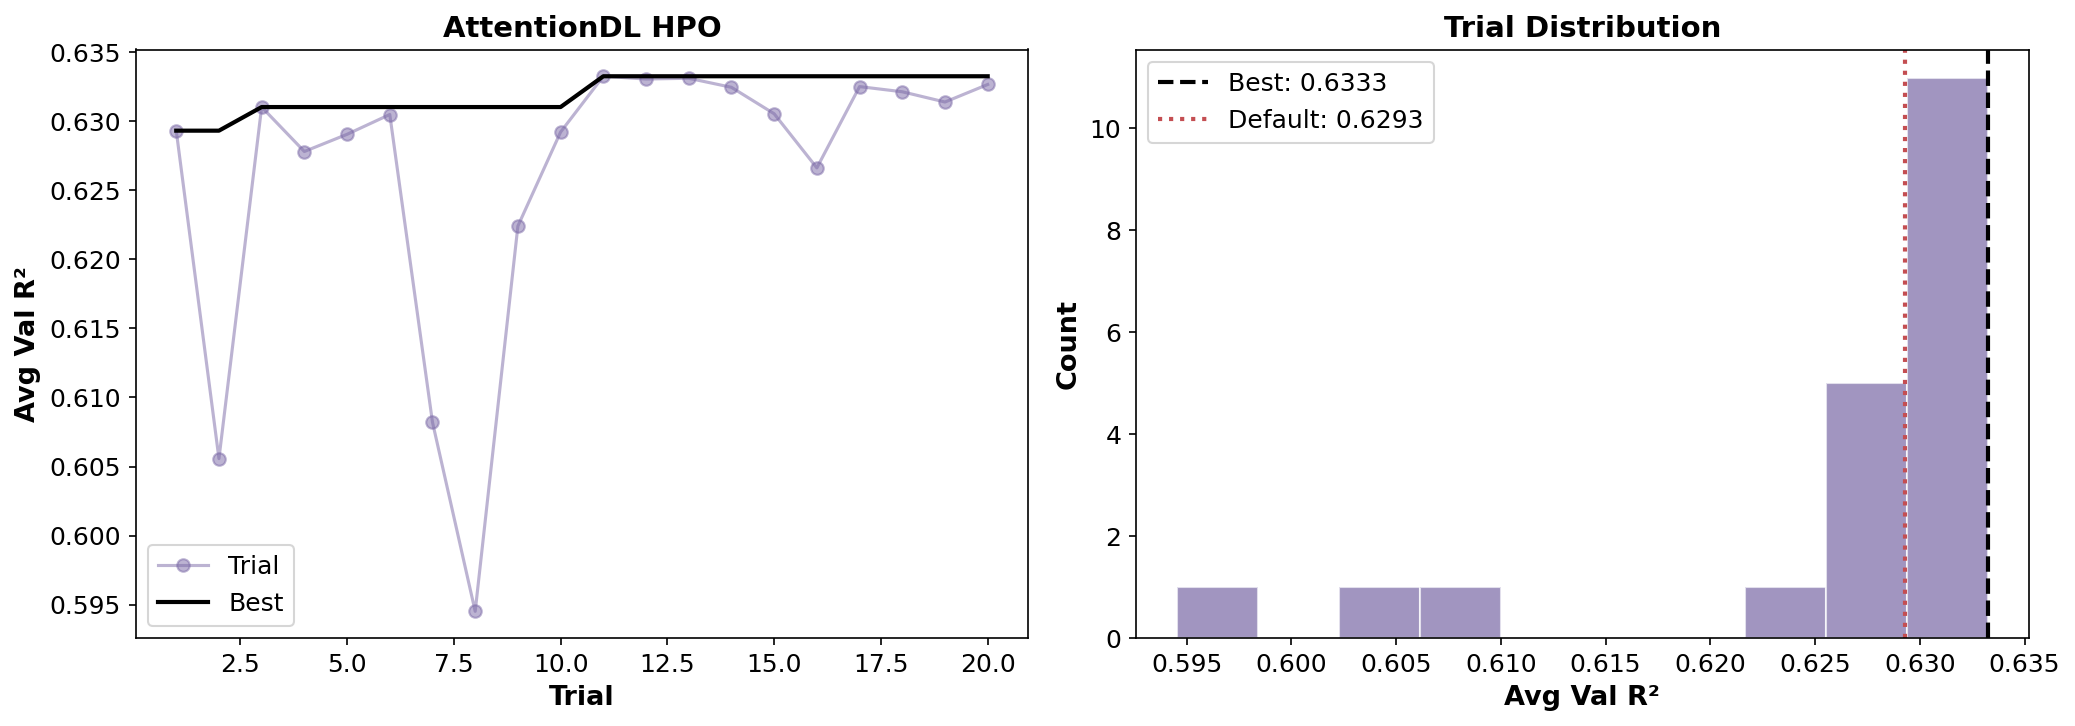

In [4]:
ms=sorted(HPO.glob('attention_dl_hpo_val_*.csv'))
if ms:
    att=pd.read_csv(ms[-1]); print(f'{len(att)} AttentionDL trials')
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    ax=axes[0]; vc=[c for c in att.columns if 'value' in c.lower()]
    if vc: ax.plot(range(1,len(att)+1),att[vc[0]],'o-',color='#7A68A6',alpha=0.5,label='Trial'); ax.plot(range(1,len(att)+1),att[vc[0]].cummax(),'-',color='black',lw=2,label='Best')
    ax.set_title('AttentionDL HPO',fontsize=14,fontweight='bold'); ax.set_xlabel('Trial',fontsize=13,fontweight='bold'); ax.set_ylabel('Avg Val R²',fontsize=13,fontweight='bold'); ax.legend()
    ax=axes[1]
    if vc and len(att)>5: ax.hist(att[vc[0]],bins=min(10,len(att)//2),color='#7A68A6',edgecolor='white',alpha=0.7); ax.axvline(att[vc[0]].max(),color='black',ls='--',lw=2,label=f'Best: {att[vc[0]].max():.4f}'); ax.axvline(att[vc[0]].iloc[0],color='#C44E52',ls=':',lw=2,label=f'Default: {att[vc[0]].iloc[0]:.4f}')
    ax.set_title('Trial Distribution',fontsize=14,fontweight='bold'); ax.set_xlabel('Avg Val R²',fontsize=13,fontweight='bold'); ax.set_ylabel('Count',fontsize=13,fontweight='bold'); ax.legend()
    plt.tight_layout(); fig.savefig(IMGS/'24_attention_hpo.png'); plt.show()
else: print('No AttentionDL HPO files')


## <span style="font-size:14pt; font-weight:bold;">4. HPO Effect Summary</span>


HPO EFFECT SUMMARY
CatBoost: 12 trials/target x 4 = 48 total
AttentionDL: 20 trials total

CatBoost: default avg R2=0.6371, tuned=0.6413 (d=+0.0042)
AttentionDL: default avg R2=0.6212, tuned=0.6264 (d=+0.0052)

Conclusion: HPO improved both modestly. Ranking unchanged.


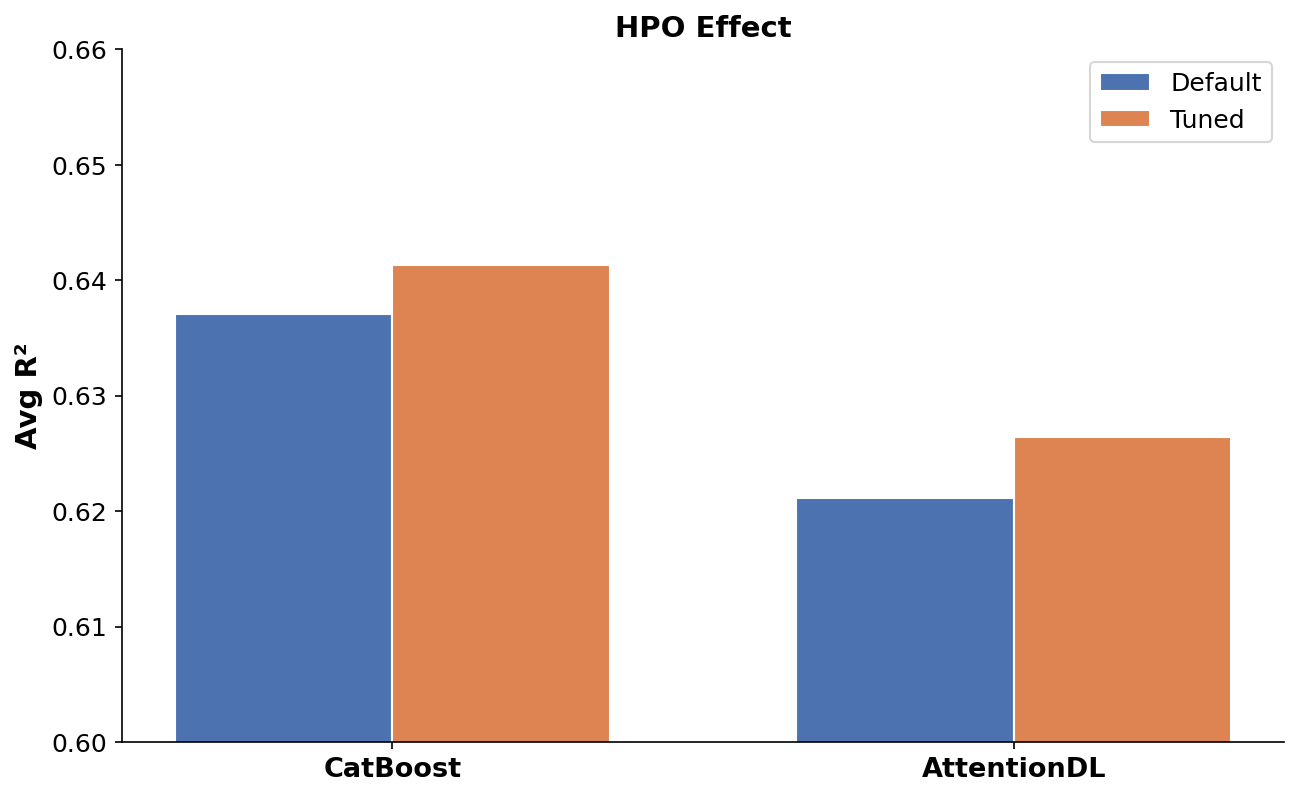

In [5]:
print('='*60); print('HPO EFFECT SUMMARY'); print('='*60)
print('CatBoost: 12 trials/target x 4 = 48 total')
print('AttentionDL: 20 trials total')
print('\nCatBoost: default avg R2=0.6371, tuned=0.6413 (d=+0.0042)')
print('AttentionDL: default avg R2=0.6212, tuned=0.6264 (d=+0.0052)')
print('\nConclusion: HPO improved both modestly. Ranking unchanged.')
fig,ax=plt.subplots(figsize=(10,6))
x=np.arange(2); ax.bar(x-0.35/2,[0.6371,0.6212],0.35,label='Default',color='#4C72B0',edgecolor='white')
ax.bar(x+0.35/2,[0.6413,0.6264],0.35,label='Tuned',color='#DD8452',edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(['CatBoost','AttentionDL'],fontsize=13,fontweight='bold')
ax.set_ylabel('Avg R²',fontsize=14,fontweight='bold'); ax.set_title('HPO Effect',fontsize=14,fontweight='bold'); ax.legend(); ax.set_ylim(0.6,0.66); sns.despine()
fig.savefig(IMGS/'24_hpo_effect.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">5. Key Findings</span>


In [6]:
print('='*70); print('NOTEBOOK 24: KEY FINDINGS'); print('='*70)
print('1. CatBoost HPO: +0.004 avg R² (12 trials/target)')
print('2. AttentionDL HPO: +0.005 avg R² (20 trials)')
print('3. HPO did NOT change the ML vs DL ranking')
print('4. Both finalists improved modestly; conclusions robust')
print('\nNotebook 24 complete.')


NOTEBOOK 24: KEY FINDINGS
1. CatBoost HPO: +0.004 avg R² (12 trials/target)
2. AttentionDL HPO: +0.005 avg R² (20 trials)
3. HPO did NOT change the ML vs DL ranking
4. Both finalists improved modestly; conclusions robust

Notebook 24 complete.
